In [1]:
import pathlib

import pandas as pd

In [2]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [3]:
output_folder = pathlib.Path("../data/outputs/")

In [4]:
def get_scores(folder: pathlib.Path) -> pd.DataFrame | None:
    scores = {}
    scores_file = folder / "scores.csv"
    if not scores_file.is_file():
        return None
    scores_df = pd.read_csv(scores_file, index_col=0)
    return scores_df

In [5]:
scores_data_list = []
untrained_data_list = []
for category in output_folder.iterdir():
    if not category.is_dir():
        continue
    for name in category.iterdir():
        if not name.is_dir():
            continue
        scores_df = get_scores(name)
        if scores_df is None:
            untrained_data_list.append({
                "category": category,
                "name": name,
            })
        else:
            scores_data_list.append(scores_df)

untrained_df = pd.DataFrame(untrained_data_list)
all_scores_df = pd.concat(scores_data_list)

In [6]:
untrained_df

,category,name
0,../data/outputs/unknown,../data/outputs/unknown/ncbi_tax_id-subspecies
1,../data/outputs/unknown,../data/outputs/unknown/unnamed_13


In [7]:
all_scores_df

,name,category,accuracy,balanced_accuracy,f1,precision,recall,matthews_corrcoef
nitrate-reduction,nitrate,reduction,0.718531,0.717327,0.692161,0.679174,0.705653,0.433345
D-mannitol-assimilation,D-mannitol,assimilation,0.828645,0.832351,0.783172,0.728916,0.846154,0.647703
acetate-assimilation,acetate,assimilation,0.739130,0.739130,0.739130,0.739130,0.739130,0.478261
sodium_citrate-assimilation,sodium_citrate,assimilation,0.764045,0.693910,0.553191,0.565217,0.541667,0.393149
potassium_gluconate-assimilation,potassium_gluconate,assimilation,0.647059,0.660394,0.594595,0.511628,0.709677,0.308843
...,...,...,...,...,...,...,...,...
arabinose-fermentation,arabinose,fermentation,0.650000,0.542857,0.222222,0.153846,0.400000,0.060523
raffinose-fermentation,raffinose,fermentation,0.831461,0.847048,0.642857,0.509434,0.870968,0.575661
cellobiose-fermentation,cellobiose,fermentation,0.923077,0.951613,0.842105,0.727273,1.000000,0.810488
lactose-fermentation,lactose,fermentation,0.813559,0.812169,0.673267,0.576271,0.809524,0.563436


In [9]:
all_scores_melt = all_scores_df.melt(id_vars=["name", "category"], var_name='score', value_name='value')
all_scores_melt

,name,category,score,value
0,nitrate,reduction,accuracy,0.718531
1,D-mannitol,assimilation,accuracy,0.828645
2,acetate,assimilation,accuracy,0.739130
3,sodium_citrate,assimilation,accuracy,0.764045
4,potassium_gluconate,assimilation,accuracy,0.647059
...,...,...,...,...
997,arabinose,fermentation,matthews_corrcoef,0.060523
998,raffinose,fermentation,matthews_corrcoef,0.575661
999,cellobiose,fermentation,matthews_corrcoef,0.810488
1000,lactose,fermentation,matthews_corrcoef,0.563436


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

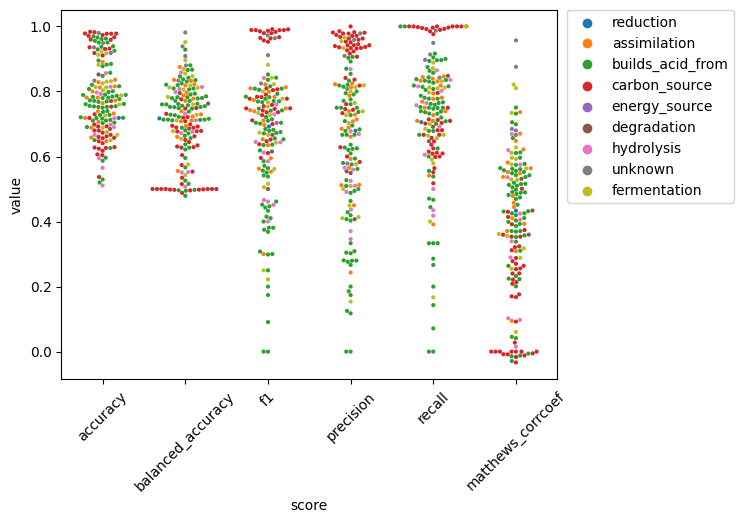

In [11]:
sns.swarmplot(data=all_scores_melt, x="score", y="value", hue="category", size=3)
plt.xticks(rotation=45);
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0);

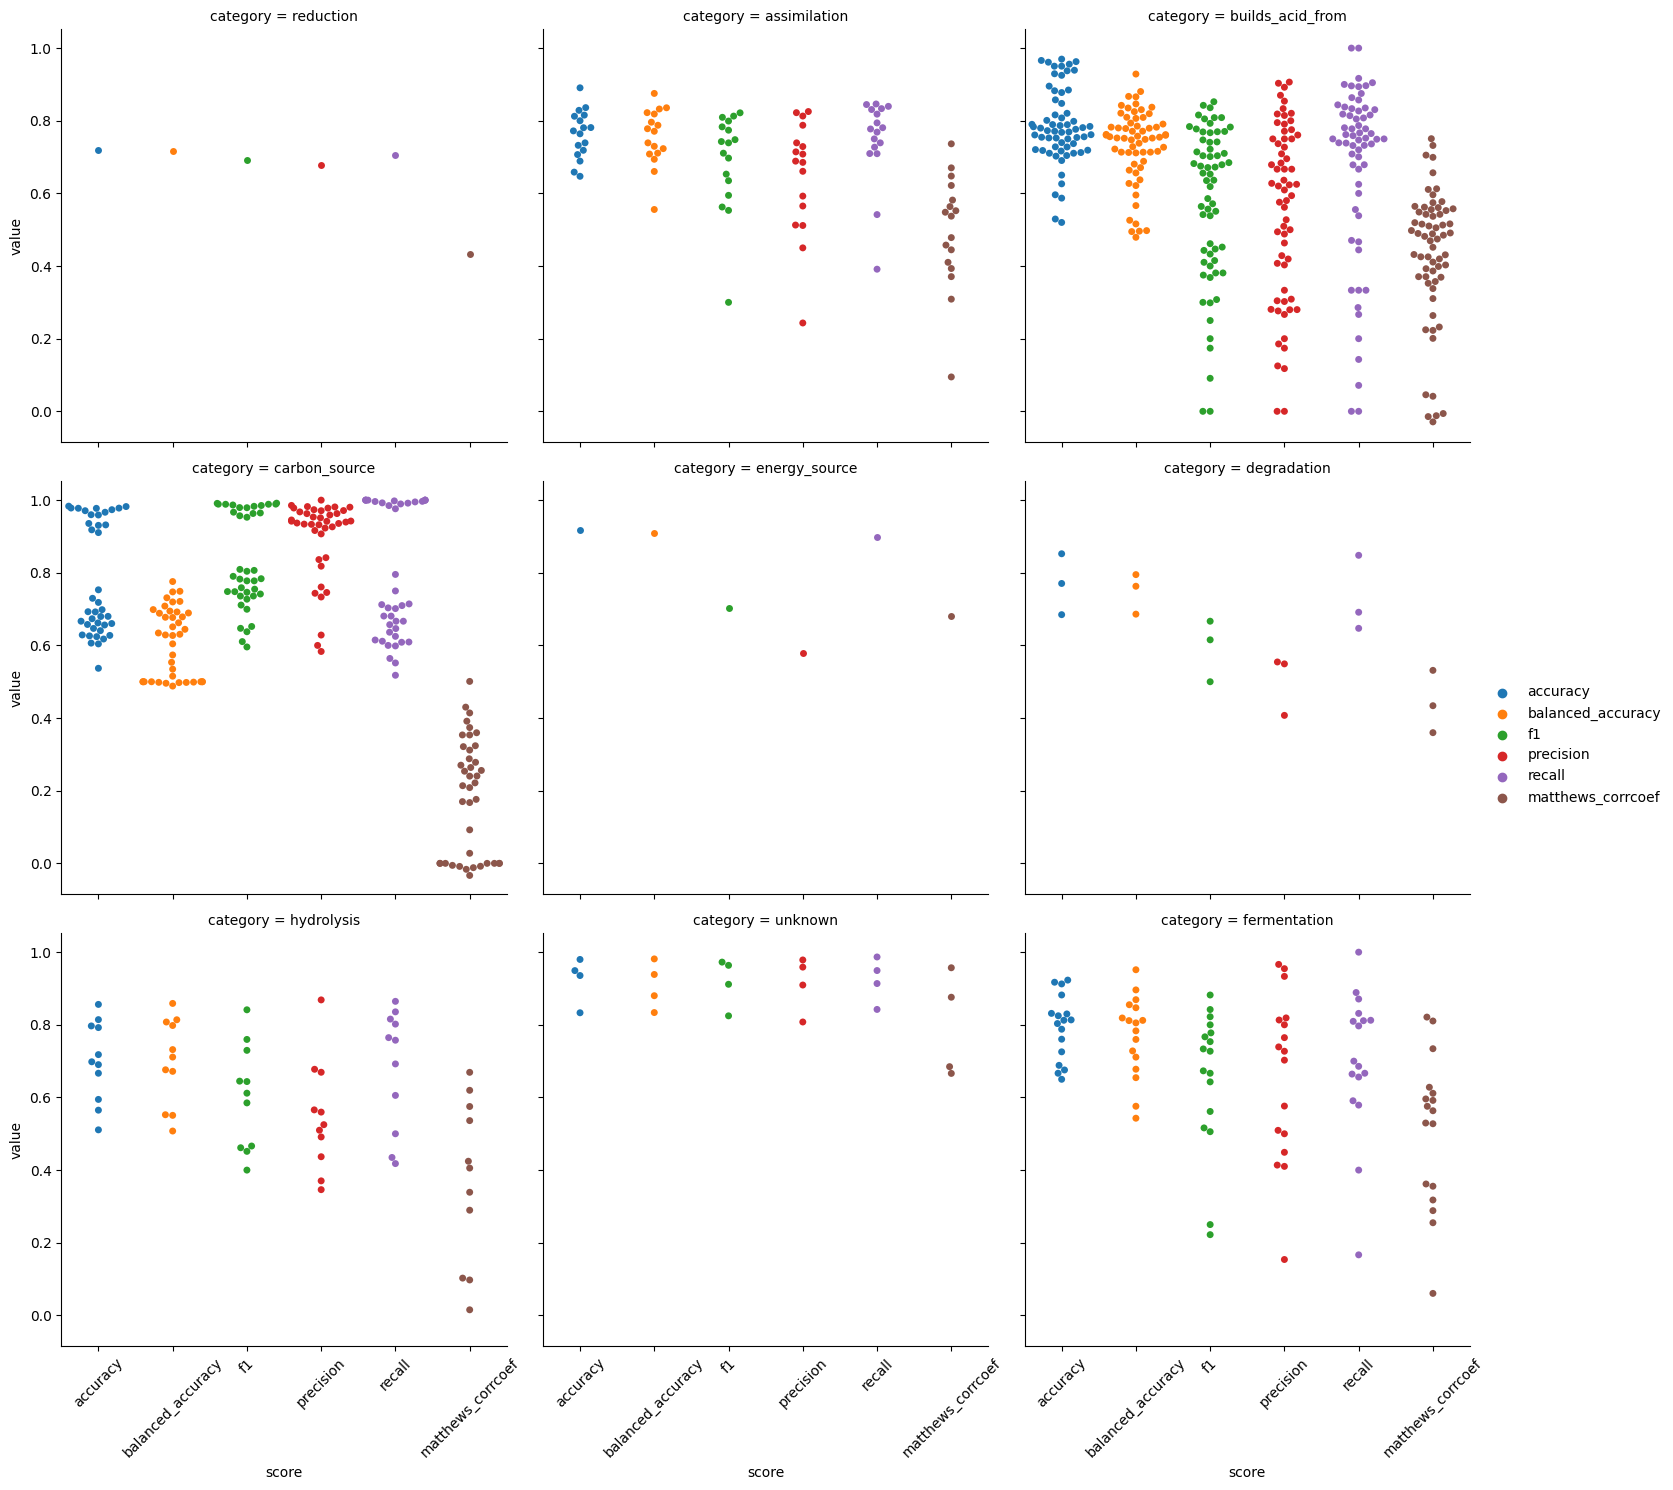

In [12]:
g = sns.catplot(data=all_scores_melt, x="score", y="value", hue="score", col="category", kind="swarm",  col_wrap=3)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45, which="both");
g.figure.tight_layout();
g.add_legend();

In [13]:
top20_scores_df = all_scores_df.sort_values(by=["matthews_corrcoef", "balanced_accuracy"], ascending=[False, False]).head(20)
top20_scores_df

,name,category,accuracy,balanced_accuracy,f1,precision,recall,matthews_corrcoef
gram_positive-unknown,gram_positive,unknown,0.979943,0.981428,0.972621,0.958869,0.986772,0.957046
spore_formation-unknown,spore_formation,unknown,0.949219,0.938570,0.911565,0.909502,0.913636,0.875953
D-mannitol-fermentation,D-mannitol,fermentation,0.912548,0.896106,0.882051,0.966292,0.811321,0.821249
cellobiose-fermentation,cellobiose,fermentation,0.923077,0.951613,0.842105,0.727273,1.000000,0.810488
D-xylose-builds_acid_from,D-xylose,builds_acid_from,0.877622,0.880429,0.852321,0.814516,0.893805,0.750580
decanoate-assimilation,decanoate,assimilation,0.890667,0.875202,0.812785,0.787611,0.839623,0.736434
D-glucose-fermentation,D-glucose,fermentation,0.882136,0.869155,0.822222,0.813187,0.831461,0.734186
palatinose-builds_acid_from,palatinose,builds_acid_from,0.884615,0.928571,0.769231,0.625000,1.000000,0.731925
L-arabinose-builds_acid_from,L-arabinose,builds_acid_from,0.857527,0.867028,0.808664,0.736842,0.896000,0.705342
methyl_beta-D-xylopyranoside-builds_acid_from,methyl_beta-D-xylopyranoside,builds_acid_from,0.955801,0.806439,0.714286,0.833333,0.625000,0.699266


In [14]:
top20_scores_df.groupby("category")["name"].count()

category
assimilation        4
builds_acid_from    5
energy_source       1
fermentation        4
hydrolysis          2
unknown             4
Name: name, dtype: int64

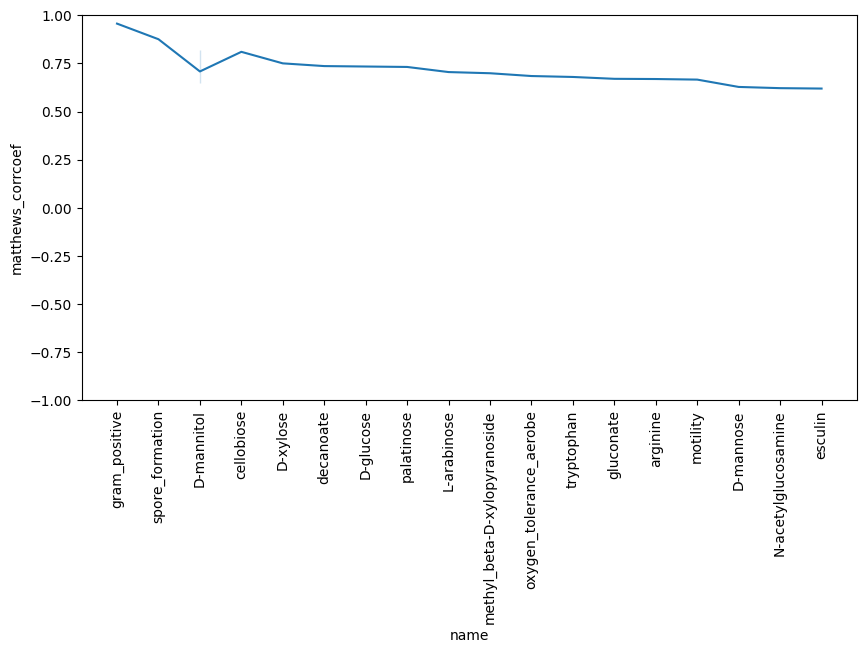

In [15]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=top20_scores_df, x="name", y="matthews_corrcoef")
plt.ylim((-1, 1))
plt.xticks(rotation=90);

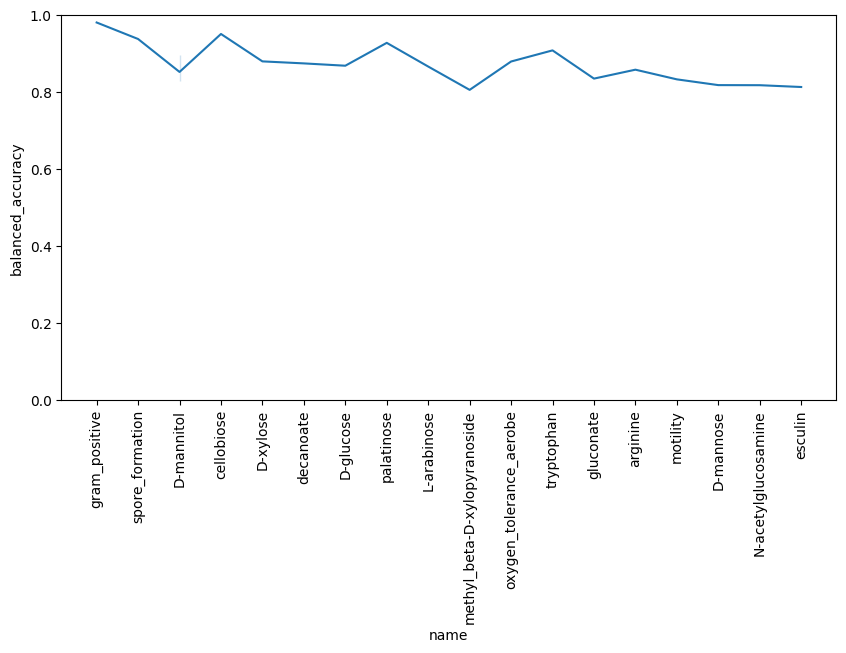

In [16]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=top20_scores_df, x="name", y="balanced_accuracy")
plt.ylim((0, 1))
plt.xticks(rotation=90);

In [21]:
import pickle
import numpy as np

In [22]:
def get_predictors(row: pd.Series, output_folder: pathlib.Path):
    cat = row["category"]
    if cat is np.nan:
        cat = "NA"
    name = row["name"]
    file_path = output_folder / f"{cat}/{name}/phenotype_predictor.pkl"
    with open(file_path, "rb") as f:
        predictor = pickle.load(f)
    return predictor

In [23]:
top20_scores_df["predictors"] = top20_scores_df.apply(get_predictors, axis=1, args=(output_folder,))

In [24]:
all_scores_df["predictors"] = all_scores_df.apply(get_predictors, axis=1, args=(output_folder,))

In [39]:
get_positives = lambda x: x.phenotype.phenotype_data.value_counts().loc[1]
get_negatives = lambda x: x.phenotype.phenotype_data.value_counts().loc[0]

In [40]:
all_scores_df["positive"] = all_scores_df["predictors"].apply(lambda x: get_positives(x))
all_scores_df["negative"] = all_scores_df["predictors"].apply(lambda x: get_negatives(x))
all_scores_df.drop(columns=["predictors"], inplace=True)

In [41]:
all_scores_df

,name,category,accuracy,balanced_accuracy,f1,precision,recall,matthews_corrcoef,positive,negative
nitrate-reduction,nitrate,reduction,0.718531,0.717327,0.692161,0.679174,0.705653,0.433345,1711,2101
D-mannitol-assimilation,D-mannitol,assimilation,0.828645,0.832351,0.783172,0.728916,0.846154,0.647703,478,825
acetate-assimilation,acetate,assimilation,0.739130,0.739130,0.739130,0.739130,0.739130,0.478261,76,76
sodium_citrate-assimilation,sodium_citrate,assimilation,0.764045,0.693910,0.553191,0.565217,0.541667,0.393149,80,216
potassium_gluconate-assimilation,potassium_gluconate,assimilation,0.647059,0.660394,0.594595,0.511628,0.709677,0.308843,104,177
...,...,...,...,...,...,...,...,...,...,...
arabinose-fermentation,arabinose,fermentation,0.650000,0.542857,0.222222,0.153846,0.400000,0.060523,17,116
raffinose-fermentation,raffinose,fermentation,0.831461,0.847048,0.642857,0.509434,0.870968,0.575661,103,488
cellobiose-fermentation,cellobiose,fermentation,0.923077,0.951613,0.842105,0.727273,1.000000,0.810488,27,101
lactose-fermentation,lactose,fermentation,0.813559,0.812169,0.673267,0.576271,0.809524,0.563436,141,447


In [42]:
all_scores_df.to_csv(output_folder / "all_scores.csv")

In [25]:
import shap

In [26]:
from trait_prediction.utils import read_rast_features

In [27]:
features, id_dict = read_rast_features("../data/raw/rast_features.tsv")

In [38]:
predictor = top20_scores_df.iloc[0]["predictors"]
predictor.phenotype.phenotype_data.value_counts().loc[1]

1259

In [28]:
def plot_shap_summary(df, name, id_dict):
    predictor = df.loc[name, "predictors"]
    feature_data = predictor.phenotype.feature_data
    clf = predictor.classifier
    feature_labels = [id_dict[c] for c in feature_data.columns]
    explainer = shap.Explainer(clf)
    shap_values = explainer(feature_data)
    shap_values.feature_names = feature_labels
    shap.summary_plot(shap_values, max_display=10, show=False);
    plt.title(f"{predictor.phenotype.name}");
    plt.plot();

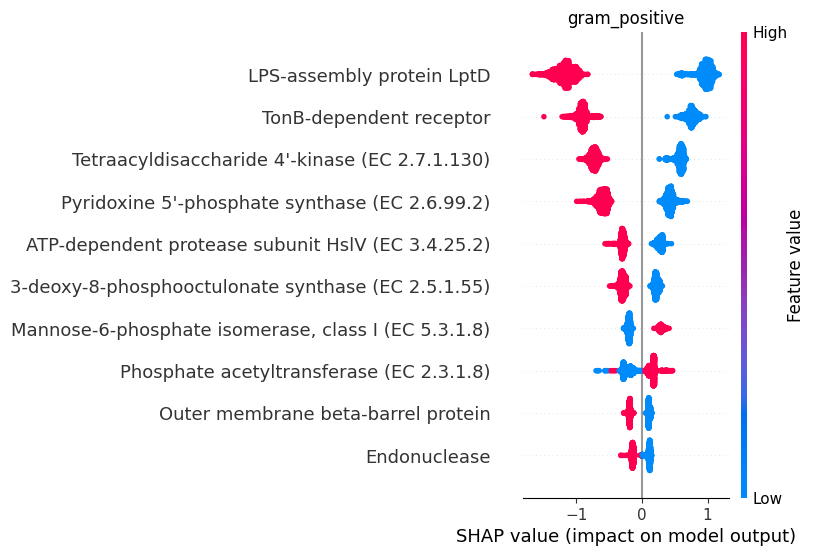

In [29]:
plot_shap_summary(top20_scores_df, "gram_positive-unknown", id_dict)

In [30]:
top20_scores_df.index

Index(['gram_positive-unknown', 'spore_formation-unknown',
       'D-mannitol-fermentation', 'cellobiose-fermentation',
       'D-xylose-builds_acid_from', 'decanoate-assimilation',
       'D-glucose-fermentation', 'palatinose-builds_acid_from',
       'L-arabinose-builds_acid_from',
       'methyl_beta-D-xylopyranoside-builds_acid_from',
       'oxygen_tolerance_aerobe-unknown', 'tryptophan-energy_source',
       'gluconate-assimilation', 'arginine-hydrolysis', 'motility-unknown',
       'D-mannitol-builds_acid_from', 'D-mannitol-assimilation',
       'D-mannose-fermentation', 'N-acetylglucosamine-assimilation',
       'esculin-hydrolysis'],
      dtype='object')

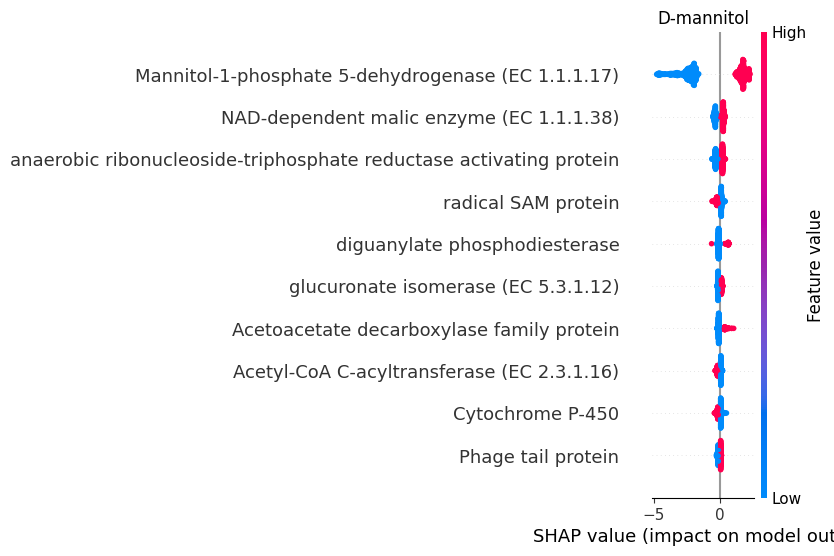

In [31]:
plot_shap_summary(top20_scores_df, "D-mannitol-fermentation", id_dict)

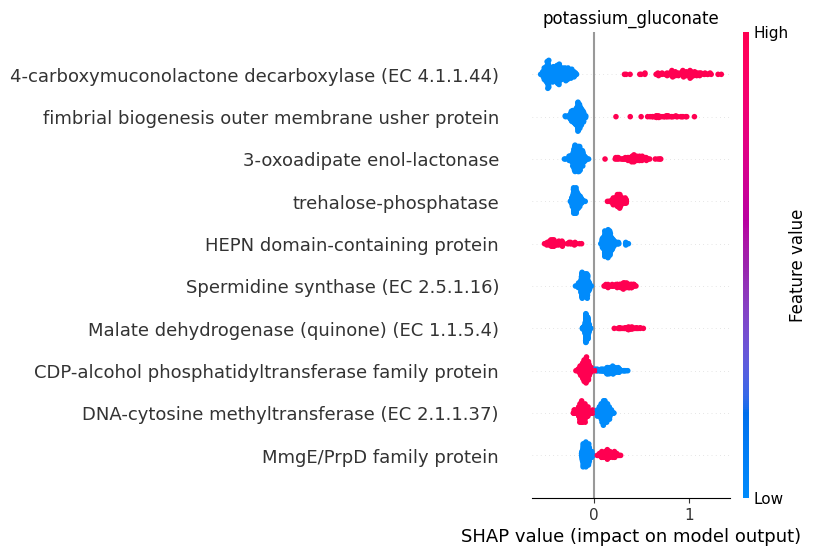

In [32]:
plot_shap_summary(all_scores_df, "potassium_gluconate-assimilation", id_dict)